In [104]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

NR = 105
NZ = 105
NT = 100
Rf = np.linspace(-2,102,NR)
Zf = np.linspace(-2,102,NZ)
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*0.1
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / t[1:] 
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / t[1:] 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z
t

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
       6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
       7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ,
       9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9])

In [98]:
NT = 1000
ndis_C_v0 = np.fromfile("ndis_C_transport_v0.bin",dtype = np.float64).reshape(100, NR - 1, NZ - 1)
fig, ax = plt.subplots()

ndis_C_log = np.log10(ndis_C_v0 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [102]:
NT = 1000
ndis_C_v01 = np.fromfile("ndis_C_transport_v0.1.bin",dtype = np.float64).reshape(100, NR - 1, NZ - 1)
fig, ax = plt.subplots()

ndis_C_log = np.log10(ndis_C_v01 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(0.001, 10.0)

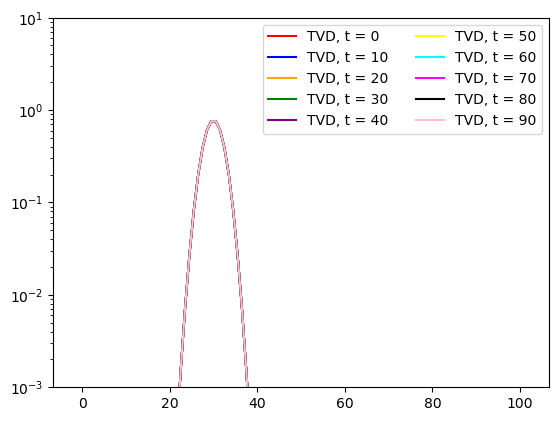

In [101]:
for i in range(10):
    plt.plot(Zc, ndis_C_v0[i*10, 30 ], label = f"TVD, t = {i*10}", c = c_lst[i])


plt.yscale("log")
plt.legend(ncol=2)
plt.ylim(1e-3,1e1)

Text(0.5, 1.0, 'D_num')

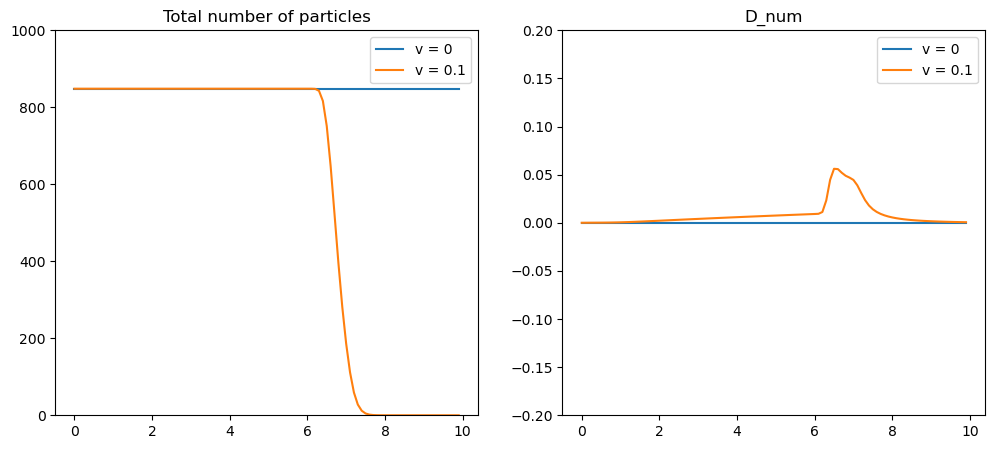

In [113]:
nd_v0 = numerical_diffusion(ndis_C_v0)
nd_v01 = numerical_diffusion(ndis_C_v01)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_v0[0], label="v = 0 ")
axes[0].plot(t, nd_v01[0], label="v = 0.1")
axes[0].set_ylim(0, 1e3)
axes[0].legend()
axes[0].set_title("Total number of particles")

axes[1].plot(t, nd_v0[5], label="v = 0")
axes[1].plot(t, nd_v01[5], label="v = 0.1")
axes[1].set_ylim(-0.2, 0.2)
axes[1].legend()
axes[1].set_title("D_num")


In [46]:
NT = 1000
ndis_C_tvd_vF1 = np.fromfile("ndis_C_dt0.1_t1000_vF1_tvd.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
fig, ax = plt.subplots()

ndis_C_tvd_log = np.log10(ndis_C_tvd_vF1 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_tvd_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [47]:
ndis_C_tvd_SSPRK2_vF1 = np.fromfile("ndis_C_dt0.1_t1000_vF1_tvd_SSPRK2.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)

fig, ax = plt.subplots()

ndis_C_log = np.log10(ndis_C_tvd_SSPRK2 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(0.001, 0.1)

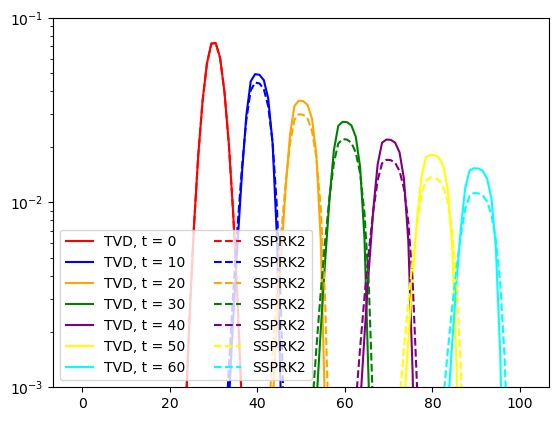

In [54]:

for i in range(7):
    plt.plot(Zc, ndis_C_tvd_vF1[i*100, 30 + i*10 ], label = f"TVD, t = {i*10}", c = c_lst[i])
for i in range(7):
    plt.plot(Zc, ndis_C_tvd_SSPRK2_vF1[i*100, 30 + i*10], label = f"SSPRK2",c = c_lst[i], linestyle="--")

plt.yscale("log")
plt.legend(ncol=2)
plt.ylim(1e-3,1e-1)

Text(0.5, 1.0, 'Pulse Centroid distance')

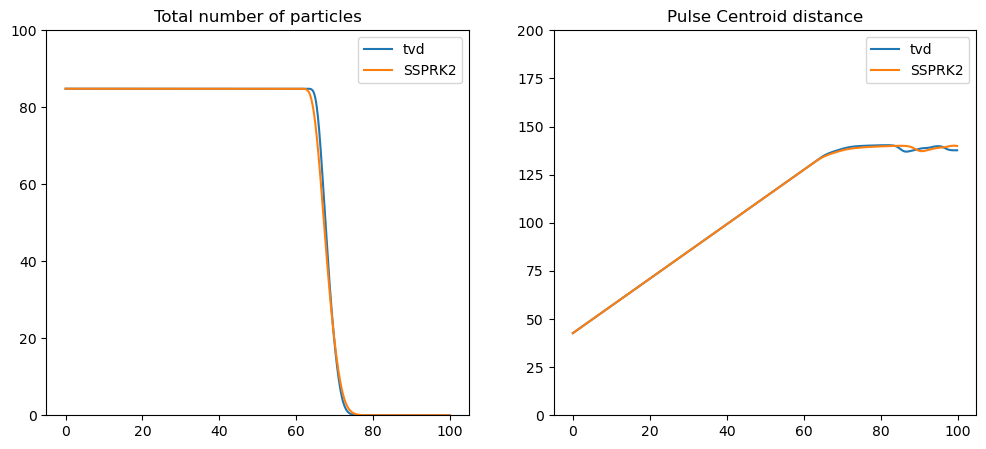

In [69]:
nd_tvd = numerical_diffusion(ndis_C_tvd_vF1)
nd_tvd_SSPRK2 = numerical_diffusion(ndis_C_tvd_SSPRK2_vF1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_tvd[0], label="tvd")
axes[0].plot(t, nd_tvd_SSPRK2[0], label="SSPRK2")
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].set_title("Total number of particles")

axes[1].plot(t, np.sqrt(nd_tvd[1]**2 + nd_tvd[2]**2), label = "tvd")
axes[1].plot(t, np.sqrt(nd_tvd_SSPRK2[1]**2 + nd_tvd_SSPRK2[2]**2), label = "SSPRK2")
axes[1].set_ylim(0, 200)
axes[1].legend()
axes[1].set_title("Pulse Centroid distance")

Text(0.5, 1.0, 'Extension')

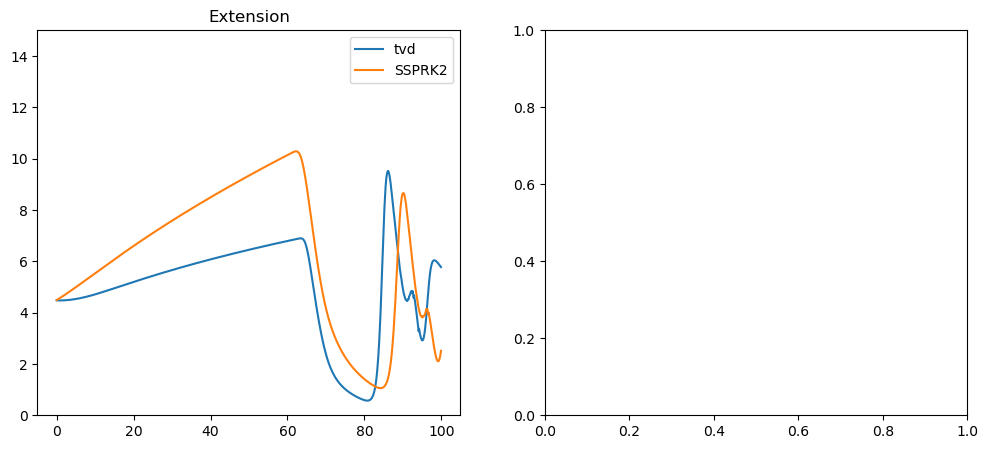

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_tvd[3], label="tvd")
axes[0].plot(t, nd_tvd_SSPRK2[3], label="SSPRK2")
axes[0].set_ylim(0, 15)
axes[0].legend()
axes[0].set_title("Extension")

# axes[1].plot(t, nd_tvd[5], label = "tvd")
# axes[1].plot(t, nd_tvd_SSPRK2[5], label = "SSPRK2")
# # axes[1].set_ylim(0, 200)
# axes[1].legend()
# axes[1].set_title("Numerical diffusion")

In [77]:
NT = 1000
ndis_C_tvd_vF1_dt05 = np.fromfile("ndis_C_dt0.05_t2000_vF1_tvd.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
fig, ax = plt.subplots()

ndis_C_log = np.log10(ndis_C_tvd_vF1_dt05 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [79]:
ndis_C_tvd_SSPRK2_vF1_dt05 = np.fromfile("ndis_C_dt0.05_t2000_vF1_tvd_SSPRK2.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)

fig, ax = plt.subplots()

ndis_C_log = np.log10(ndis_C_tvd_SSPRK2_vF1_dt05 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_C_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

Text(0.5, 1.0, 'Pulse Centroid distance')

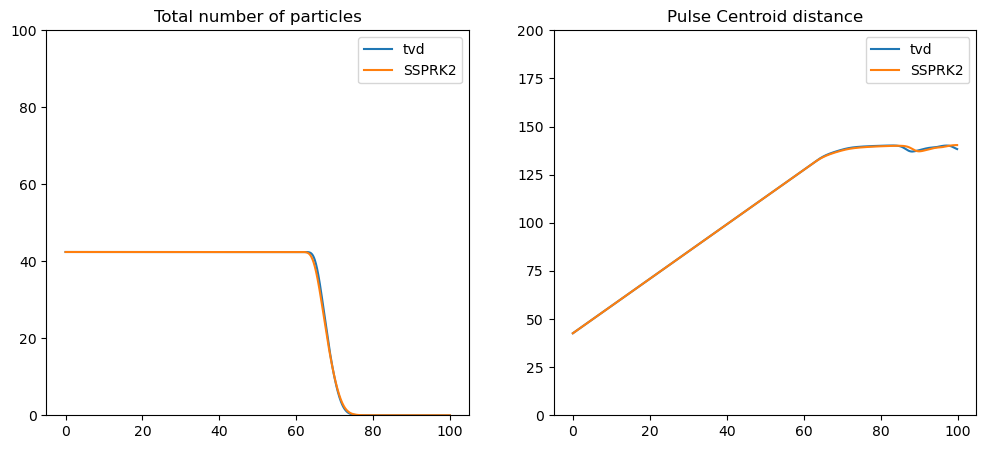

In [80]:
nd_tvd_dt05 = numerical_diffusion(ndis_C_tvd_vF1_dt05)
nd_tvd_SSPRK2_dt05 = numerical_diffusion(ndis_C_tvd_SSPRK2_vF1_dt05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_tvd_dt05[0], label="tvd")
axes[0].plot(t, nd_tvd_SSPRK2_dt05[0], label="SSPRK2")
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].set_title("Total number of particles")

axes[1].plot(t, np.sqrt(nd_tvd_dt05[1]**2 + nd_tvd_dt05[2]**2), label = "tvd")
axes[1].plot(t, np.sqrt(nd_tvd_SSPRK2_dt05[1]**2 + nd_tvd_SSPRK2_dt05[2]**2), label = "SSPRK2")
axes[1].set_ylim(0, 200)
axes[1].legend()
axes[1].set_title("Pulse Centroid distance")

Text(0.5, 1.0, 'Extension')

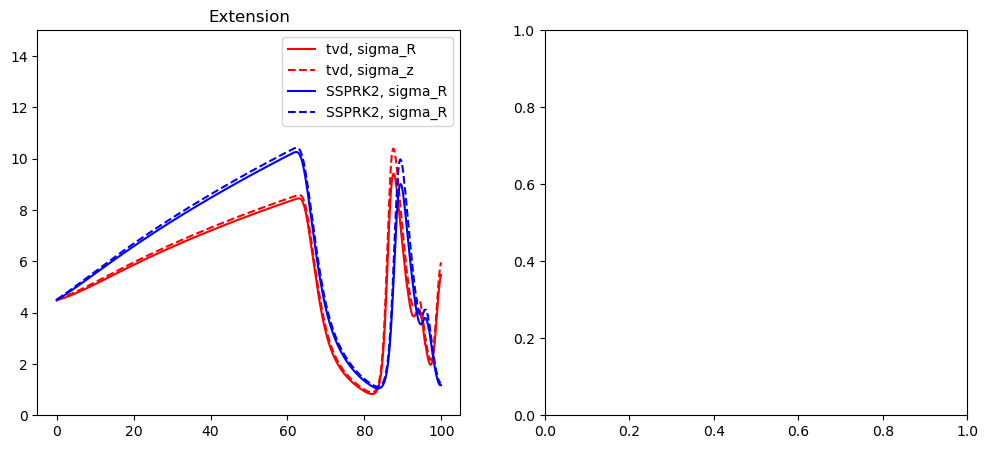

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_tvd_dt05[3], label="tvd, sigma_R", c = "red")
axes[0].plot(t, nd_tvd_dt05[4], label="tvd, sigma_z", c = "red", linestyle="--")

axes[0].plot(t, nd_tvd_SSPRK2_dt05[3], label="SSPRK2, sigma_R", c = "blue")
axes[0].plot(t, nd_tvd_SSPRK2_dt05[4], label="SSPRK2, sigma_R", c = "blue", linestyle="--")

axes[0].set_ylim(0, 15)
axes[0].legend()
axes[0].set_title("Extension")

# axes[1].plot(t, nd_tvd_dt05[5], label = "tvd")
# axes[1].plot(t, nd_tvd_SSPRK2_dt05[5], label = "SSPRK2")
# # axes[1].set_ylim(0, 200)
# axes[1].legend()
# axes[1].set_title("Numerical diffusion")

In [94]:
(76.05 - 2.49 - 3.19 + 2.49 + 1.27 + 2.99 + 2.29 + 0.79 + 0.95 + 9.99 + 0.79 + 20.75) /5

22.536

1 + 1

In [90]:
76.05 - 2.49 - 3.19

70.37

In [91]:
2.49 + 1.27 + 2.99 + 2.29 + 0.79 + 0.95 + 9.99 + 0.79 

21.559999999999995

In [95]:
22.5 - 20.75

1.75